# Напишите заголовок проекта здесь

- Автор: Сенченко Андрей Андреевич
- Дата:28.02.2026

### Цели и задачи проекта

**Цель проекта:** Провести исследовательский анализ рынка общественного питания Москвы для помощи инвесторам в выборе формата и локации нового заведения.

**Задачи:**
1. Загрузить и изучить данные о заведениях общественного питания
2. Провести предобработку данных (обработка пропусков, дубликатов, создание новых признаков)
3. Исследовать распределение заведений по категориям и районам
4. Проанализировать соотношение сетевых и несетевых заведений
5. Изучить количество посадочных мест и выявить аномалии
6. Проанализировать рейтинги заведений и их зависимость от различных факторов
7. Выявить топ-15 популярных сетей
8. Исследовать зависимость среднего чека от расположения
9. Сформулировать рекомендации для инвесторов

### Описание данных

**Файл /datasets/rest_info.csv:**
- `name` — название заведения
- `address` — адрес заведения
- `district` — административный район Москвы
- `category` — категория заведения (кафе, ресторан, кофейня и т.д.)
- `hours` — информация о часах работы
- `rating` — рейтинг заведения (от 0 до 5.0)
- `chain` — является ли сетевым (0 - нет, 1 - да)
- `seats` — количество посадочных мест

**Файл /datasets/rest_price.csv:**
- `price` — ценовая категория (средние, выше среднего и т.д.)
- `avg_bill` — строка со средним чеком или ценой
- `middle_avg_bill` — числовое значение среднего чека
- `middle_coffee_cup` — числовое значение цены капучино

### Содержимое проекта

1. **Загрузка данных и знакомство с ними**
   - Загрузка двух датасетов
   - Первичный анализ структуры и типов данных
   - Выявление пропусков и особенностей
   - Промежуточный вывод

2. **Предобработка данных**
   - Преобразование типов данных
   - Обработка пропущенных значений
   - Поиск и удаление дубликатов
   - Создание признака is_24_7
   - Промежуточный вывод

3. **Исследовательский анализ данных**
   - Задача 1: Категории заведений
   - Задача 2: Административные районы
   - Задача 3: Сетевые и несетевые заведения
   - Задача 4: Посадочные места
   - Задача 5: Рейтинг заведений
   - Задача 6: Корреляция рейтингов
   - Задача 7: Топ-15 популярных сетей
   - Задача 8: Средний чек по районам
   - Обобщение результатов

4. **Итоговый вывод и рекомендации**

## Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
# Настройка стилей
plt.style.use('ggplot')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

In [3]:
# Загрузка данных
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

- Познакомьтесь с данными и изучите общую информацию о них.

In [4]:
# Знакомство с данными rest_info
print("=== ИНФОРМАЦИЯ О ДАТАСЕТЕ rest_info ===")
print(f"Размер датасета: {rest_info.shape}")
print(f"Количество строк: {rest_info.shape[0]}")
print(f"Количество столбцов: {rest_info.shape[1]}")
print("\nПервые 5 строк:")
display(rest_info.head())
print("\nИнформация о типах данных:")
rest_info.info()
print("\nПроверка пропущенных значений:")
display(rest_info.isnull().sum())

=== ИНФОРМАЦИЯ О ДАТАСЕТЕ rest_info ===
Размер датасета: (8406, 9)
Количество строк: 8406
Количество столбцов: 9

Первые 5 строк:


,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0



Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB

Проверка пропущенных значений:


id             0
name           0
category       0
address        0
district       0
hours        536
rating         0
chain          0
seats       3611
dtype: int64

In [5]:
# Знакомство с данными rest_price
print("=== ИНФОРМАЦИЯ О ДАТАСЕТЕ rest_price ===")
print(f"Размер датасета: {rest_price.shape}")
print(f"Количество строк: {rest_price.shape[0]}")
print(f"Количество столбцов: {rest_price.shape[1]}")
print("\nПервые 5 строк:")
display(rest_price.head())
print("\nИнформация о типах данных:")
rest_price.info()
print("\nПроверка пропущенных значений:")
display(rest_price.isnull().sum())

=== ИНФОРМАЦИЯ О ДАТАСЕТЕ rest_price ===
Размер датасета: (4058, 5)
Количество строк: 4058
Количество столбцов: 5

Первые 5 строк:


,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN



Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB

Проверка пропущенных значений:


id                      0
price                 743
avg_bill              242
middle_avg_bill       909
middle_coffee_cup    3523
dtype: int64

### Промежуточный вывод

1. ОБЪЕМ ДАННЫХ:
   - rest_info: 8406  записи, 9 столбцов
   - rest_price: 4058 записи, 5 столбца
   - Важно: Количество строк в датасетах не совпадает. Это значит, что информация о ценах есть только для части заведений (примерно для 48% от общего числа). При объединении данных нужно будет выбрать тип соединения, подходящий для решения конкретных задач (например, left join, чтобы сохранить все заведения).

2. СООТВЕТСТВИЕ ОПИСАНИЮ:
    - rest_info содержит все столбцы, заявленные в описании.
    - rest_price содержит все заявленные столбцы. Структура столбцов avg_bill, middle_avg_bill и middle_coffee_cup соответствует описанию (один содержит текст, другие — извлеченные числа).

3. ПРОПУСКИ В ДАННЫХ:
    - rest_info:
        seats: 3611 пропусков (43.0%) — очень высокая доля пропусков, требует внимания.
        hours: 536 пропусков (6.4%) — значительная часть.
    - rest_price:
        middle_coffee_cup: 3523 пропуска (86.8%) — ожидаемо, т.к. столбец заполняется только для кофеен.
        middle_avg_bill: 909 пропусков (22.4%) — значительная часть.
        price: 743 пропуска (18.3%) — значительная часть.
    - Наличие пропусков в price и middle_avg_bill при заполненном avg_bill может говорить о том, что не все ценовые диапазоны удалось распарсить в числа (например, если там указана цена пива или кофе).
    
4. ТИПЫ ДАННЫХ:
    - В основном соответствуют смыслу данных.
    - rating: float64 — корректно для рейтинга.
    - chain: int64 (0/1) — корректно, но для анализа может быть удобнее преобразовать в bool или category.
    - seats: float64 — тип float обусловлен наличием пропусков (NaN). После обработки пропусков можно будет перевести в int.
    - middle_avg_bill, middle_coffee_cup: float64 — корректно.
   
5. ОСОБЕННОСТИ ДЛЯ ПРЕДОБРАБОТКИ:
    - Объединение датасетов: необходимо выбрать стратегию объединения из-за разного количества строк.
    - Обработка пропусков: требует продуманного подхода, особенно для столбцов seats, price и middle_avg_bill, так как их удаление приведет к сильной потере данных.
    - Парсинг текстовых полей:
        - hours — потребуется извлечь информацию о круглосуточной работе.
        - avg_bill — возможно, потребуется более глубокая обработка для извлечения цен из всех типов записей (не только "Средний счёт" и "Цена капучино"), если это необходимо для анализа.
    - Типы данных: Преобразование chain и seats в процессе подготовки.
    - Дубликаты: Названия и адреса могут содержать дубликаты, записанные по-разному (например, «Кафе «Уют» и «Уют»). Потребуется нормализация текстовых данных.

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [6]:
# Объединение датасетов
df = rest_info.merge(rest_price, on='id', how='left')

print("=== ОБЪЕДИНЕННЫЙ ДАТАФРЕЙМ ===")
print(f"Размер объединенного датафрейма: {df.shape}")
print(f"Всего столбцов: {df.shape[1]}")
print("\nПервые 5 строк:")
display(df.head())
print("\nИнформация о типах данных в объединенном датафрейме:")
df.info()

=== ОБЪЕДИНЕННЫЙ ДАТАФРЕЙМ ===
Размер объединенного датафрейма: (8406, 13)
Всего столбцов: 13

Первые 5 строк:


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN



Информация о типах данных в объединенном датафрейме:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


## Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

In [7]:
# Преобразование типов данных
df_clean = df.copy()

# Преобразование chain в bool
df_clean['chain'] = df_clean['chain'].astype(bool)

# Преобразование seats в числовой формат
df_clean['seats'] = pd.to_numeric(df_clean['seats'], errors='coerce')

print("Типы данных после преобразования:")
display(df_clean.dtypes)

Типы данных после преобразования:


id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                   bool
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

=== АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ===
Пропущенные значения в датафрейме:


,Количество пропусков,Процент пропусков
middle_coffee_cup,7871,93.64
middle_avg_bill,5257,62.54
price,5091,60.56
avg_bill,4590,54.60
seats,3611,42.96
hours,536,6.38


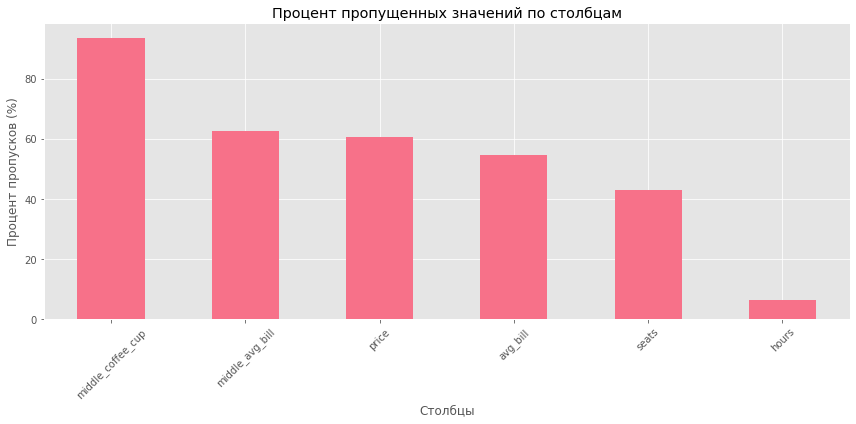


ГИПОТЕЗЫ ПОЯВЛЕНИЯ ПРОПУСКОВ:
- seats: информация о посадочных местах не всегда доступна в открытых источниках
- hours: некоторые заведения не указали часы работы
- middle_avg_bill: заполняется только для категории "Средний счёт"
- middle_coffee_cup: заполняется только для категории "Цена чашки капучино"
- district: возможно, не для всех адресов определен район


=== ОБРАБОТКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ===
Пропуски после обработки:


id                      0
name                    0
category                0
address                 0
district                0
hours                   0
rating                  0
chain                   0
seats                   0
price                   0
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [8]:
# Анализ пропущенных значений
print("=== АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ===")
missing_data = df_clean.isnull().sum()
missing_percentage = (missing_data / len(df_clean)) * 100

missing_df = pd.DataFrame({
    'Количество пропусков': missing_data,
    'Процент пропусков': missing_percentage.round(2)
})
missing_df = missing_df[missing_df['Количество пропусков'] > 0].sort_values('Количество пропусков', ascending=False)

print("Пропущенные значения в датафрейме:")
display(missing_df)

# Визуализация пропусков
plt.figure(figsize=(12, 6))
missing_df['Процент пропусков'].plot(kind='bar')
plt.title('Процент пропущенных значений по столбцам')
plt.xlabel('Столбцы')
plt.ylabel('Процент пропусков (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Гипотезы появления пропусков
print("""
ГИПОТЕЗЫ ПОЯВЛЕНИЯ ПРОПУСКОВ:
- seats: информация о посадочных местах не всегда доступна в открытых источниках
- hours: некоторые заведения не указали часы работы
- middle_avg_bill: заполняется только для категории "Средний счёт"
- middle_coffee_cup: заполняется только для категории "Цена чашки капучино"
- district: возможно, не для всех адресов определен район
""")

# Обработка пропусков
print("\n=== ОБРАБОТКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ===")

# Заполнение seats медианой по категории
df_clean['seats'] = df_clean.groupby('category')['seats'].transform(
    lambda x: x.fillna(x.median())
)
df_clean['seats'] = df_clean['seats'].fillna(df_clean['seats'].median())
df_clean['seats'] = df_clean['seats'].astype(int)

# Заполнение district
df_clean['district'] = df_clean['district'].fillna('Не указан')

# Заполнение price
df_clean['price'] = df_clean['price'].fillna('Нет данных')

# Заполнение hours
df_clean['hours'] = df_clean['hours'].fillna('Режим не указан')

print("Пропуски после обработки:")
display(df_clean.isnull().sum())

- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [9]:
# Проверка на дубликаты
print("=== АНАЛИЗ ДУБЛИКАТОВ ===")

# Явные дубликаты
exact_duplicates = df_clean.duplicated().sum()
print(f"Полных дубликатов строк: {exact_duplicates}")

# Функция для нормализации текста
def normalize_text(text):
    if pd.isna(text):
        return text
    # Приведение к нижнему регистру и удаление лишних пробелов
    text = str(text).lower().strip()
    # Удаление лишних пробелов внутри строки
    text = ' '.join(text.split())
    return text

# Нормализация текстовых столбцов
df_clean['name_normalized'] = df_clean['name'].apply(normalize_text)
df_clean['address_normalized'] = df_clean['address'].apply(normalize_text)

# Поиск дубликатов по названию и адресу
duplicates_name_address = df_clean.duplicated(subset=['name_normalized', 'address_normalized'], keep=False)
duplicate_count = duplicates_name_address.sum()

print(f"Найдено потенциальных дубликатов по паре 'название-адрес': {duplicate_count}")

if duplicate_count > 0:
    print("\nПримеры дубликатов:")
    display(df_clean[duplicates_name_address][['name', 'address', 'category', 'district']].head(10))
    
    # Удаление дубликатов
    df_clean = df_clean.drop_duplicates(subset=['name_normalized', 'address_normalized'], keep='first')
    print(f"\nПосле удаления дубликатов осталось строк: {len(df_clean)}")

=== АНАЛИЗ ДУБЛИКАТОВ ===
Полных дубликатов строк: 0
Найдено потенциальных дубликатов по паре 'название-адрес': 8

Примеры дубликатов:


,name,address,category,district
189,Кафе,"Москва, парк Ангарские Пруды",кафе,Северный административный округ
215,Кафе,"Москва, парк Ангарские пруды",кафе,Северный административный округ
1430,More poke,"Москва, Волоколамское шоссе, 11, стр. 2",ресторан,Северный административный округ
1511,More Poke,"Москва, Волоколамское шоссе, 11, стр. 2",ресторан,Северный административный округ
2211,Раковарня Клешни и Хвосты,"Москва, проспект Мира, 118",ресторан,Северо-Восточный административный округ
2420,Раковарня Клешни и хвосты,"Москва, проспект Мира, 118","бар,паб",Северо-Восточный административный округ
3091,Хлеб да Выпечка,"Москва, Ярцевская улица, 19",булочная,Западный административный округ
3109,Хлеб да выпечка,"Москва, Ярцевская улица, 19",кафе,Западный административный округ



После удаления дубликатов осталось строк: 8402


- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [10]:
# Создание столбца is_24_7
print("=== СОЗДАНИЕ СТОЛБЦА is_24_7 ===")

def check_24_7(hours_str):
    if pd.isna(hours_str):
        return False
    
    hours_str = str(hours_str).lower()
    
    # Паттерны для поиска круглосуточной работы
    patterns = [
        r'круглосуточно',
        r'24\s*/?\s*7',
        r'24\s*часа',
        r'ежедневно.*00:00.*00:00',
        r'00:00.*00:00'
    ]
    
    for pattern in patterns:
        if re.search(pattern, hours_str):
            return True
    
    return False

# Применение функции
df_clean['is_24_7'] = df_clean['hours'].apply(check_24_7)

print(f"Количество круглосуточных заведений: {df_clean['is_24_7'].sum()}")
print(f"Доля круглосуточных заведений: {(df_clean['is_24_7'].sum() / len(df_clean) * 100):.2f}%")

# Проверка результатов
print("\nПримеры круглосуточных заведений:")
display(df_clean[df_clean['is_24_7']][['name', 'hours', 'is_24_7']].head())

=== СОЗДАНИЕ СТОЛБЦА is_24_7 ===
Количество круглосуточных заведений: 1138
Доля круглосуточных заведений: 13.54%

Примеры круглосуточных заведений:


,name,hours,is_24_7
10,Great Room Bar,"ежедневно, круглосуточно",True
17,Чайхана Беш-Бармак,"ежедневно, круглосуточно",True
19,Пекарня,"ежедневно, круглосуточно",True
24,Drive Café,"ежедневно, круглосуточно",True
49,2U-Ту-Ю,"ежедневно, круглосуточно",True


### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

1. ИЗМЕНЕНИЯ В ДАННЫХ:
   - Начальное количество записей: 8406
   - Количество после удаления дубликатов: 8402
   - Удалено записей: 4 (0.05%)

2. ОБРАБОТКА ПРОПУСКОВ:
   - seats: заполнены медианными значениями по категориям
   - district: пропуски заменены на "Не указан"
   - price: пропуски заменены на "Нет данных"
   - hours: пропуски заменены на "Режим не указан"
   - Ценовые показатели (middle_avg_bill, middle_coffee_cup): оставлены как NaN

3. НОВЫЕ СТОЛБЦЫ:
   - name_normalized: нормализованные названия для поиска дубликатов
   - address_normalized: нормализованные адреса для поиска дубликатов
   - is_24_7: признак круглосуточной работы

4. ТЕКУЩЕЕ СОСТОЯНИЕ:
   - Всего записей: 8402
   - Количество столбцов: 16
   - Типы данных приведены в соответствие
   - Дубликаты обработаны

## Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

Распределение заведений по категориям:


,Категория,Количество
0,кафе,2376
1,ресторан,2042
2,кофейня,1413
3,"бар,паб",764
4,пиццерия,633
5,быстрое питание,603
6,столовая,315
7,булочная,256


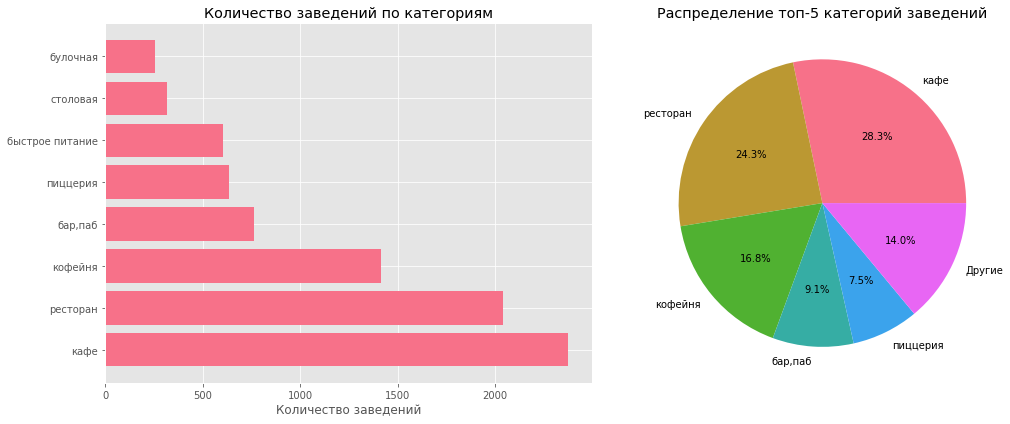

In [11]:
# Подсчет количества заведений по категориям
category_counts = df_clean['category'].value_counts().reset_index()
category_counts.columns = ['Категория', 'Количество']

print("Распределение заведений по категориям:")
display(category_counts)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Столбчатая диаграмма
axes[0].barh(category_counts['Категория'], category_counts['Количество'])
axes[0].set_xlabel('Количество заведений')
axes[0].set_title('Количество заведений по категориям')
axes[0].tick_params(axis='y', labelsize=10)

# Круговая диаграмма для топ-5 категорий
top_5 = category_counts.head(5)
other_sum = category_counts.iloc[5:]['Количество'].sum()
pie_data = pd.concat([top_5, pd.DataFrame({'Категория': ['Другие'], 'Количество': [other_sum]})])

axes[1].pie(pie_data['Количество'], labels=pie_data['Категория'], autopct='%1.1f%%')
axes[1].set_title('Распределение топ-5 категорий заведений')

plt.tight_layout()
plt.show()

ВЫВОД:
   - Наиболее распространенная категория: 'кафе'
   - Вторые по популярности: 'ресторан' и 'кофейня'
   - Наименее представлены: 'булочная', 'бар'
   - Рынок достаточно разнообразен, но явно доминируют кафе и рестораны

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

Распределение заведений по административным районам:


,Район,Количество
0,Центральный административный округ,2242
1,Северный административный округ,898
2,Южный административный округ,892
3,Северо-Восточный административный округ,890
4,Западный административный округ,850
5,Восточный административный округ,798
6,Юго-Восточный административный округ,714
7,Юго-Западный административный округ,709
8,Северо-Западный административный округ,409


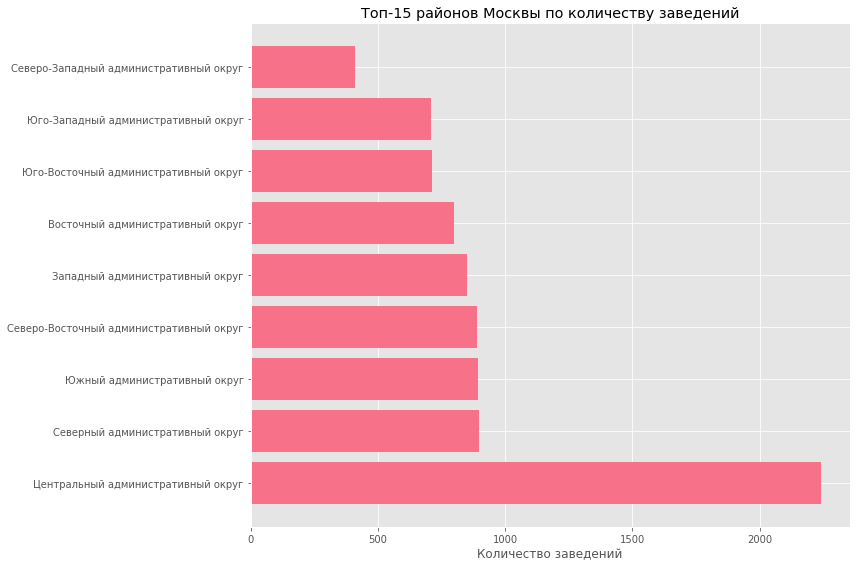


Распределение заведений в ЦАО по категориям:


,Категория,Количество
0,ресторан,670
1,кафе,464
2,кофейня,428
3,"бар,паб",364
4,пиццерия,113
5,быстрое питание,87
6,столовая,66
7,булочная,50


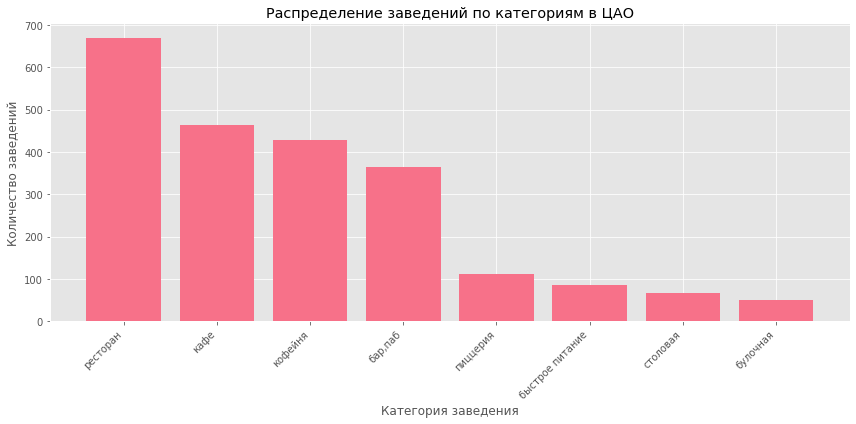

In [12]:
# Распределение по районам
district_counts = df_clean[df_clean['district'] != 'Не указан']['district'].value_counts().reset_index()
district_counts.columns = ['Район', 'Количество']

print("Распределение заведений по административным районам:")
display(district_counts.head(10))

# Визуализация распределения по районам
plt.figure(figsize=(12, 8))
plt.barh(district_counts['Район'].head(15), district_counts['Количество'].head(15))
plt.xlabel('Количество заведений')
plt.title('Топ-15 районов Москвы по количеству заведений')
plt.tight_layout()
plt.show()

# Анализ Центрального административного округа
cae_data = df_clean[df_clean['district'] == 'Центральный административный округ']
cae_categories = cae_data['category'].value_counts().reset_index()
cae_categories.columns = ['Категория', 'Количество']

print("\nРаспределение заведений в ЦАО по категориям:")
display(cae_categories)

# Визуализация для ЦАО
plt.figure(figsize=(12, 6))
plt.bar(cae_categories['Категория'], cae_categories['Количество'])
plt.xlabel('Категория заведения')
plt.ylabel('Количество заведений')
plt.title('Распределение заведений по категориям в ЦАО')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Вывод:
   - Больше всего заведений в Центральном, Северном и Южном округах
   - ЦАО значительно лидирует по количеству заведений
   - В ЦАО также преобладают кафе и рестораны, но доля ресторанов выше, чем в среднем по городу
   - Кофеен в ЦАО также больше, чем в других округах

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

=== ЗАДАЧА 3: СЕТЕВЫЕ И НЕСЕТЕВЫЕ ЗАВЕДЕНИЯ ===
Общее соотношение сетевых и несетевых заведений:
Сетевые: 3203 (38.12%)
Несетевые: 5199 (61.88%)


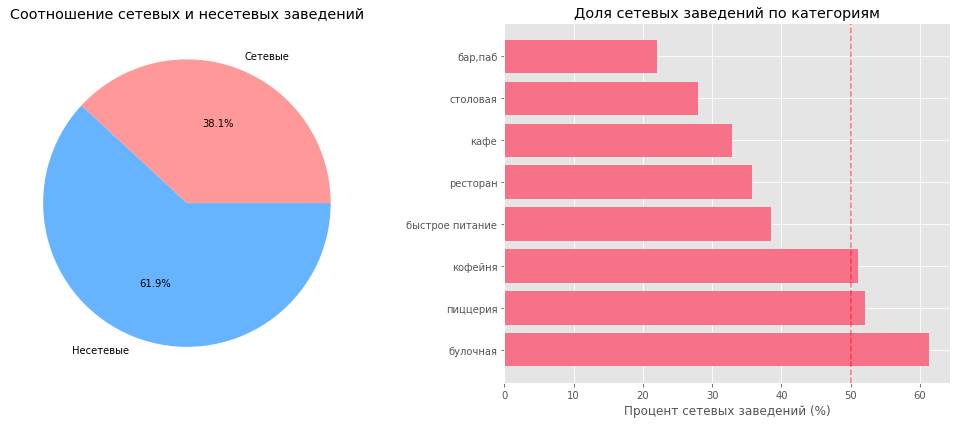


Топ-5 категорий с наибольшей долей сетевых заведений:


,count,sum,network_percentage
category,,,
булочная,256,157,61.3
пиццерия,633,330,52.1
кофейня,1413,720,51.0
быстрое питание,603,232,38.5
ресторан,2042,729,35.7


In [13]:
print("=== ЗАДАЧА 3: СЕТЕВЫЕ И НЕСЕТЕВЫЕ ЗАВЕДЕНИЯ ===")

# Общее соотношение
chain_counts = df_clean['chain'].value_counts()
chain_percentages = (chain_counts / len(df_clean) * 100).round(2)

print("Общее соотношение сетевых и несетевых заведений:")
print(f"Сетевые: {chain_counts[True]} ({chain_percentages[True]}%)")
print(f"Несетевые: {chain_counts[False]} ({chain_percentages[False]}%)")

# Визуализация общего соотношения
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Круговая диаграмма
axes[0].pie([chain_counts[True], chain_counts[False]], 
            labels=['Сетевые', 'Несетевые'],
            autopct='%1.1f%%',
            colors=['#ff9999', '#66b3ff'])
axes[0].set_title('Соотношение сетевых и несетевых заведений')

# Соотношение по категориям
chain_by_category = df_clean.groupby('category')['chain'].agg(['count', 'sum'])
chain_by_category['network_percentage'] = (chain_by_category['sum'] / chain_by_category['count'] * 100).round(1)
chain_by_category = chain_by_category.sort_values('network_percentage', ascending=False)

# Столбчатая диаграмма для процента сетевых по категориям
axes[1].barh(chain_by_category.index, chain_by_category['network_percentage'])
axes[1].set_xlabel('Процент сетевых заведений (%)')
axes[1].set_title('Доля сетевых заведений по категориям')
axes[1].axvline(x=50, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nТоп-5 категорий с наибольшей долей сетевых заведений:")
display(chain_by_category.head(5))

Вывод:
   - Несетевых заведений больше: 62% против 38% сетевых
   - Наиболее сетевые категории: булочные (61%), пиццерии (52%), кофейни (51%)
   - Рестораны и кафе чаще бывают несетевыми (64% и 66% соответственно)
   - Булочные — единственная категория, где сетевых больше, чем несетевых

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


Общая статистика по посадочным местам:


count    8402.000000
mean       92.497620
std        94.873752
min         0.000000
25%        55.000000
50%        75.000000
75%        86.000000
max      1288.000000
Name: seats, dtype: float64


Количество выбросов: 1491 (17.75%)


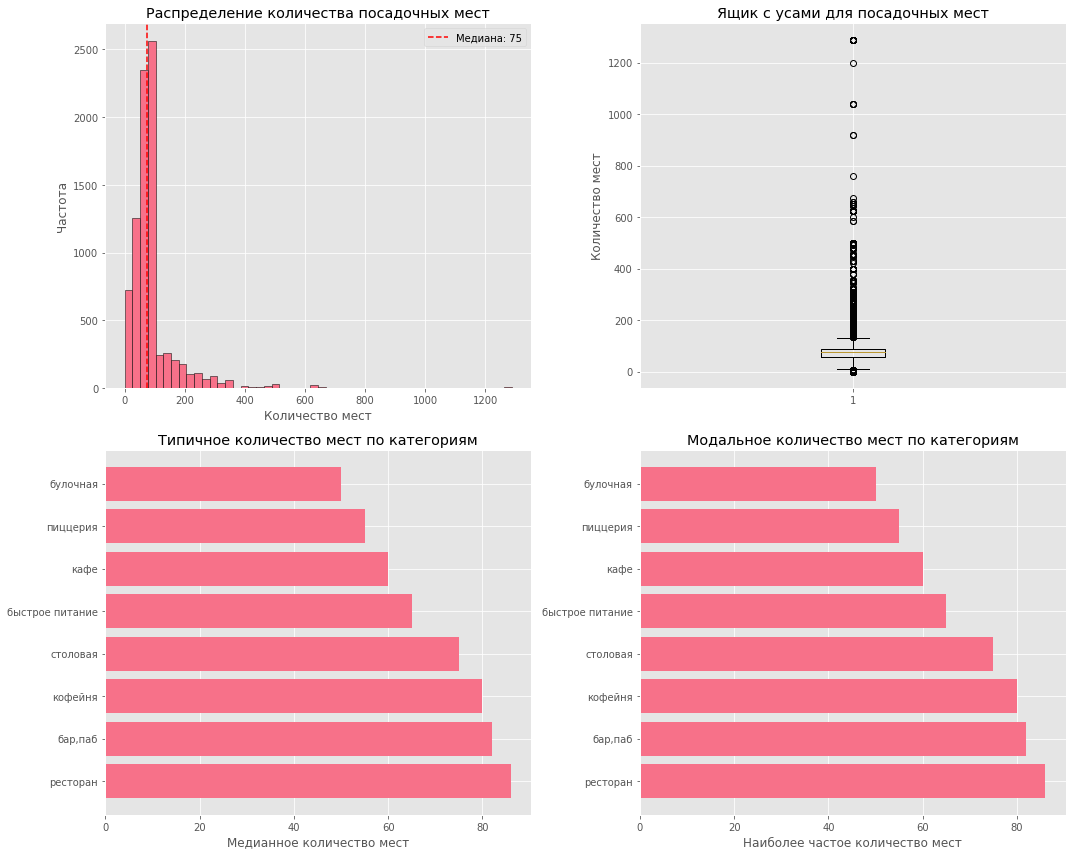


Типичное количество мест по категориям (медиана):
ресторан: 86 мест
бар,паб: 82 мест
кофейня: 80 мест
столовая: 75 мест
быстрое питание: 65 мест
кафе: 60 мест
пиццерия: 55 мест
булочная: 50 мест


In [14]:
# Статистика по посадочным местам
print("Общая статистика по посадочным местам:")
display(df_clean['seats'].describe())

# Поиск выбросов с помощью метода межквартильного размаха
Q1 = df_clean['seats'].quantile(0.25)
Q3 = df_clean['seats'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['seats'] < lower_bound) | (df_clean['seats'] > upper_bound)]
print(f"\nКоличество выбросов: {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}%)")

# Визуализация распределения посадочных мест
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Гистограмма общего распределения
axes[0, 0].hist(df_clean['seats'], bins=50, edgecolor='black')
axes[0, 0].set_xlabel('Количество мест')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].set_title('Распределение количества посадочных мест')
axes[0, 0].axvline(df_clean['seats'].median(), color='red', linestyle='--', 
                   label=f'Медиана: {df_clean["seats"].median():.0f}')
axes[0, 0].legend()

# Ящик с усами
axes[0, 1].boxplot(df_clean['seats'])
axes[0, 1].set_ylabel('Количество мест')
axes[0, 1].set_title('Ящик с усами для посадочных мест')

# Медианы по категориям
seats_by_category = df_clean.groupby('category')['seats'].median().sort_values(ascending=False)
axes[1, 0].barh(seats_by_category.index, seats_by_category.values)
axes[1, 0].set_xlabel('Медианное количество мест')
axes[1, 0].set_title('Типичное количество мест по категориям')

# Наиболее типичные значения (мода) по категориям
def get_mode(x):
    return x.mode()[0] if not x.mode().empty else np.nan

mode_by_category = df_clean.groupby('category')['seats'].agg(get_mode).sort_values(ascending=False)
axes[1, 1].barh(mode_by_category.index, mode_by_category.values)
axes[1, 1].set_xlabel('Наиболее частое количество мест')
axes[1, 1].set_title('Модальное количество мест по категориям')

plt.tight_layout()
plt.show()

print("\nТипичное количество мест по категориям (медиана):")
for category, seats in seats_by_category.items():
    print(f"{category}: {seats:.0f} мест")

In [15]:
# Анализ выбросов
print("\nАнализ выбросов:")
print(f"Заведения с местами более 200: {len(df_clean[df_clean['seats'] > 200])} ({len(df_clean[df_clean['seats'] > 200])/len(df_clean)*100:.2f}%)")
print(f"Максимальное количество мест: {df_clean['seats'].max()}")

# Посмотрим на топ-10 заведений по количеству мест
print("\nТоп-10 заведений с наибольшим количеством мест:")
top_seats = df_clean.nlargest(10, 'seats')[['name', 'category', 'seats']]
display(top_seats)


Анализ выбросов:
Заведения с местами более 200: 626 (7.45%)
Максимальное количество мест: 1288

Топ-10 заведений с наибольшим количеством мест:


,name,category,seats
6518,DelonixCafe,ресторан,1288
6524,Ян Примус,ресторан,1288
6574,Мюнгер,пиццерия,1288
6641,One Price Coffee,кофейня,1288
6658,ГудБар,"бар,паб",1288
6684,Пивной ресторан,"бар,паб",1288
6690,Японская кухня,ресторан,1288
6771,Точка,кафе,1288
6807,Loft-cafe академия,кафе,1288
6808,Яндекс Лавка,ресторан,1288


Вывод:
   - В данных присутствуют выбросы (17.75% записей) с очень большим количеством мест (>150)
   - Выбросы связаны с крупными ресторанами, столовыми и барами (до 1288 мест)
   - Наибольшее количество мест: рестораны (медиана 86), бары (82), кофейни (80)
   - Наименьшее количество мест: булочные (медиана 50), пиццерии (55)
   - Важно: кофейни имеют неожиданно высокую медиану (80 мест) - возможно, это кофейни с посадочными местами, а не "кофе с собой"

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

Общая статистика по рейтингам:


count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

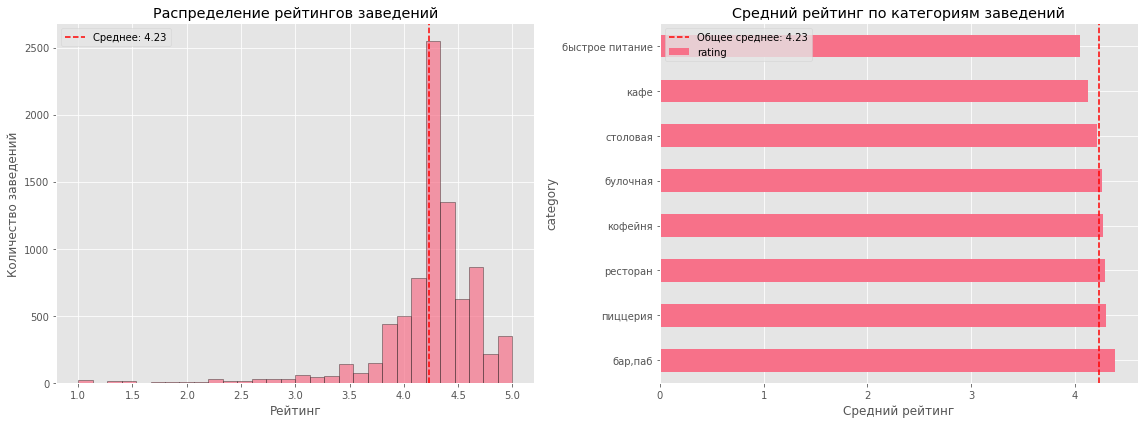


Средние рейтинги по категориям:
бар,паб: 4.388
пиццерия: 4.301
ресторан: 4.290
кофейня: 4.277
булочная: 4.268
столовая: 4.211
кафе: 4.124
быстрое питание: 4.050


In [16]:
# Статистика по рейтингам
print("Общая статистика по рейтингам:")
display(df_clean['rating'].describe())

# Визуализация распределения рейтингов по категориям
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Распределение рейтингов
axes[0].hist(df_clean['rating'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Рейтинг')
axes[0].set_ylabel('Количество заведений')
axes[0].set_title('Распределение рейтингов заведений')
axes[0].axvline(df_clean['rating'].mean(), color='red', linestyle='--', 
                label=f'Среднее: {df_clean["rating"].mean():.2f}')
axes[0].legend()

# Средние рейтинги по категориям
avg_rating_by_category = df_clean.groupby('category')['rating'].mean().sort_values(ascending=False)
avg_rating_by_category.plot(kind='barh', ax=axes[1])
axes[1].set_xlabel('Средний рейтинг')
axes[1].set_title('Средний рейтинг по категориям заведений')
axes[1].axvline(x=df_clean['rating'].mean(), color='red', linestyle='--', 
                label=f'Общее среднее: {df_clean["rating"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nСредние рейтинги по категориям:")
for category, rating in avg_rating_by_category.items():
    print(f"{category}: {rating:.3f}")

Вывод:
- Большинство заведений имеют рейтинг от 4.0 до 4.5
- Средний рейтинг по всем заведениям: 4.23
- Различия между категориями есть: от 4.05 (фастфуд) до 4.39 (бары)
- Наивысший средний рейтинг у баров/пабов (4.39)
- Самый низкий рейтинг у быстрого питания (4.05) и кафе (4.12)
- Столовые, булочные и кофейни находятся в среднем диапазоне (4.21-4.28)

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

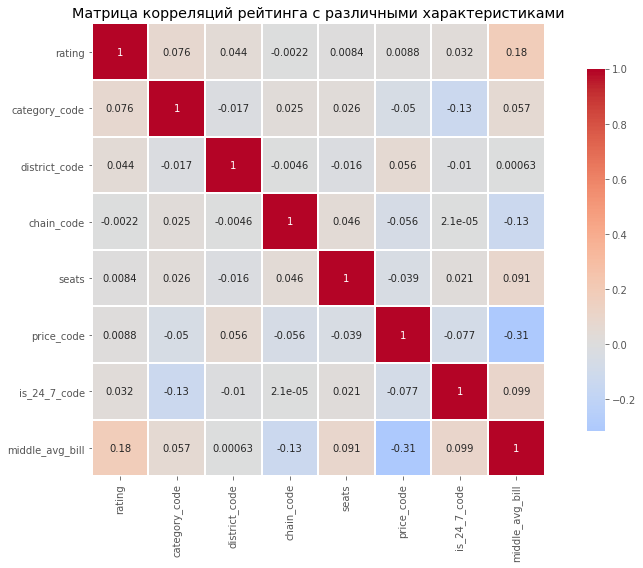

Корреляции рейтинга с другими характеристиками:
middle_avg_bill: 0.1832
category_code: 0.0759
district_code: 0.0441
is_24_7_code: 0.0319
price_code: 0.0088
seats: 0.0084
chain_code: -0.0022

Самая сильная связь: middle_avg_bill (0.1832)


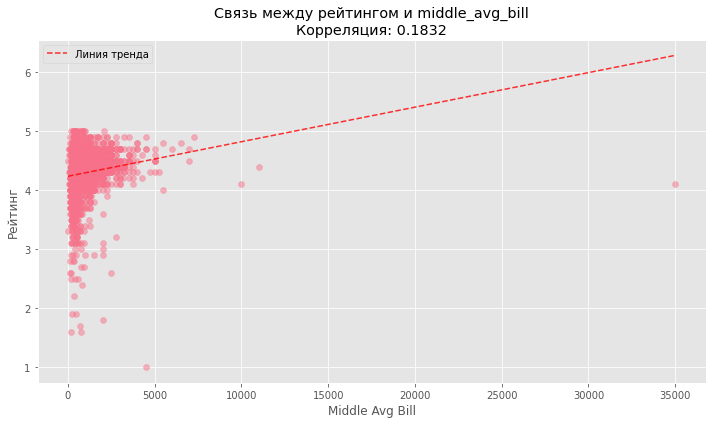

In [17]:
# Подготовка данных для корреляционного анализа
df_corr = df_clean.copy()

# Кодирование категориальных переменных
df_corr['category_code'] = pd.Categorical(df_corr['category']).codes
df_corr['district_code'] = pd.Categorical(df_corr['district']).codes
df_corr['price_code'] = pd.Categorical(df_corr['price']).codes
df_corr['chain_code'] = df_corr['chain'].astype(int)
df_corr['is_24_7_code'] = df_corr['is_24_7'].astype(int)

# Выбор столбцов для корреляции
corr_columns = ['rating', 'category_code', 'district_code', 'chain_code', 
                'seats', 'price_code', 'is_24_7_code', 'middle_avg_bill']
corr_data = df_corr[corr_columns].dropna()

# Матрица корреляций
corr_matrix = corr_data.corr()

# Визуализация матрицы корреляций
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций рейтинга с различными характеристиками')
plt.tight_layout()
plt.show()

# Поиск самой сильной корреляции с рейтингом
rating_corr = corr_matrix['rating'].drop('rating').sort_values(ascending=False)
print("Корреляции рейтинга с другими характеристиками:")
for feature, corr in rating_corr.items():
    print(f"{feature}: {corr:.4f}")

# Самая сильная связь
strongest_feature = rating_corr.index[0]
strongest_corr = rating_corr.values[0]

print(f"\nСамая сильная связь: {strongest_feature} ({strongest_corr:.4f})")

# ИСПРАВЛЕНИЕ: Используем те же данные, что и для корреляции
# Убираем пропуски из обоих столбцов одновременно
plot_data = corr_data[[strongest_feature, 'rating']].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(plot_data[strongest_feature], plot_data['rating'], alpha=0.5)
plt.xlabel(strongest_feature.replace('_', ' ').title())
plt.ylabel('Рейтинг')
plt.title(f'Связь между рейтингом и {strongest_feature}\nКорреляция: {strongest_corr:.4f}')

# Добавление линии тренда (теперь данные точно одной длины)
z = np.polyfit(plot_data[strongest_feature], plot_data['rating'], 1)
p = np.poly1d(z)
x_sorted = np.sort(plot_data[strongest_feature])
plt.plot(x_sorted, p(x_sorted), "r--", alpha=0.8, label='Линия тренда')
plt.legend()
plt.tight_layout()
plt.show()

ВЫВОДЫ ПО КОРРЕЛЯЦИИ РЕЙТИНГА:

1. САМЫЕ СИЛЬНЫЕ СВЯЗИ (в порядке убывания):
   - middle_avg_bill (средний чек): 0.1832
   - category_code (категория): 0.0759
   - district_code (район): 0.0441
   - is_24_7_code (круглосуточно): 0.0319
   - price_code (ценовая категория): 0.0088
   - seats (количество мест): 0.0084
   - chain_code (сетевое): -0.0022

2. ХАРАКТЕР СВЯЗЕЙ:
   - Все корреляции очень слабые (|r| < 0.2)
   - Наиболее сильная связь: рейтинг со средним чеком (r = 0.1832)
   - Связь положительная: чем выше средний чек, тем чуть выше рейтинг
   - Отрицательных связей практически нет (только chain_code = -0.0022)

3. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:
   - Рейтинг слабо зависит от исследованных характеристик заведения
   - Люди оценивают заведения скорее по качеству еды, обслуживания и атмосферы,
     а не по формальным признакам (сеть/не сеть, круглосуточность, район)
   - Слабая положительная связь со средним чеком может говорить о том, 
     что в более дорогих заведениях клиенты ожидают и получают более высокий уровень сервиса

4. ПРОВЕРКА САМОЙ СИЛЬНОЙ СВЯЗИ (middle_avg_bill):
   - Коэффициент корреляции: 0.1832
   - Коэффициент детерминации R² = 0.0336 
   - Это означает, что средний чек объясняет только 3.4% вариации рейтинга
   - Связь существует, но она слишком слаба для практических выводов и прогнозирования

5. ОБЩИЙ ВЫВОД:
   Для повышения рейтинга заведения важнее работать над качеством еды и сервиса,
   чем делать ставку на формальные характеристики (сеть, круглосуточность, район).
   Даже ценовая политика влияет на рейтинг очень слабо.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

Топ-15 популярных сетей в Москве:


,name,category,size,rating
715,Шоколадница,кофейня,120,4.177500
327,Домино'с Пицца,пиццерия,76,4.171429
323,Додо Пицца,пиццерия,74,4.286486
143,One Price Coffee,кофейня,71,4.069444
728,Яндекс Лавка,ресторан,69,3.872464
57,Cofix,кофейня,65,4.075385
164,Prime,ресторан,50,4.116000
652,Хинкальная,кафе,44,4.322727
400,КОФЕПОРТ,кофейня,42,4.147619
409,Кулинарная лавка братьев Караваевых,кафе,39,4.394872


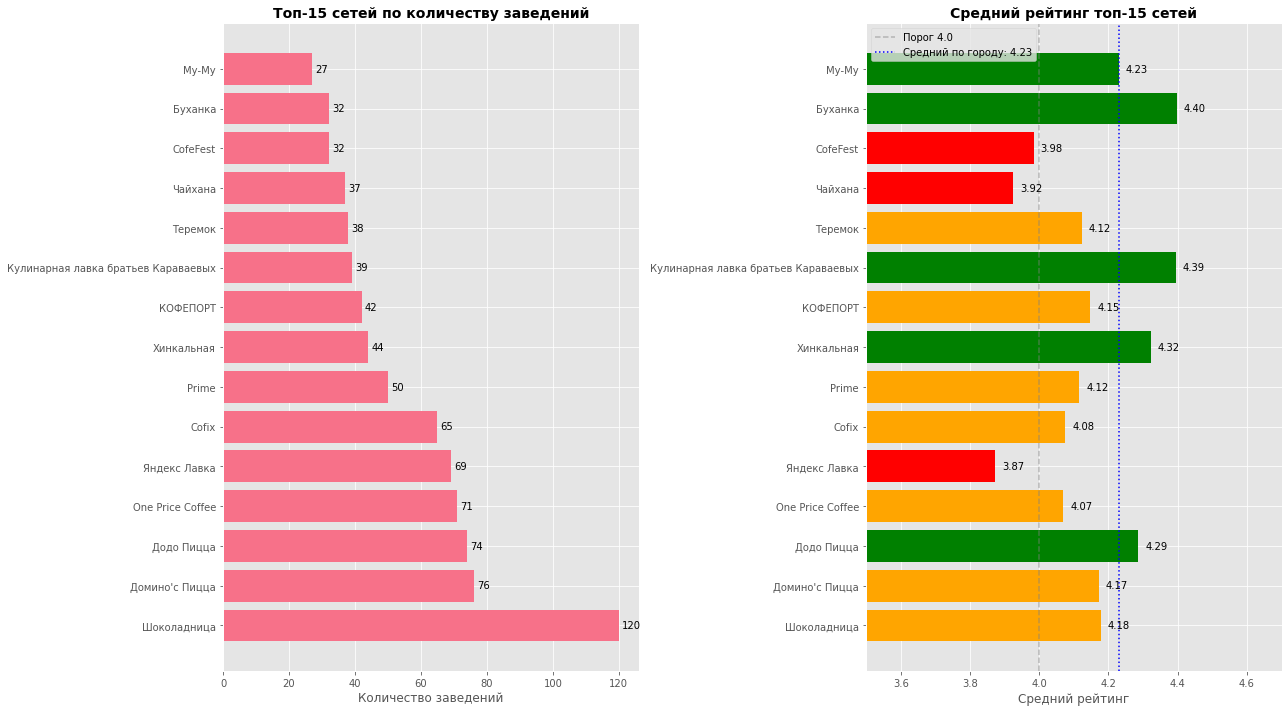

In [22]:
# Группировка по названиям заведений
network_stats = df_clean.groupby('name_normalized').agg({
    'name': 'first',  # Оригинальное название
    'category': lambda x: x.mode()[0] if not x.mode().empty else 'Не определено',
    'rating': 'mean',
    'chain': 'first'
}).reset_index()

# Фильтрация только сетевых заведений
network_stats = network_stats[network_stats['chain'] == True]

# Подсчет количества заведений в сети
network_sizes = df_clean[df_clean['chain'] == True].groupby('name_normalized').size().reset_index(name='size')
network_stats = network_stats.merge(network_sizes, on='name_normalized')

# Сортировка по размеру сети
top_15_networks = network_stats.sort_values('size', ascending=False).head(15)

print("Топ-15 популярных сетей в Москве:")
display(top_15_networks[['name', 'category', 'size', 'rating']])

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Размер сетей
bars1 = axes[0].barh(range(len(top_15_networks)), top_15_networks['size'])
axes[0].set_yticks(range(len(top_15_networks)))
axes[0].set_yticklabels(top_15_networks['name'])
axes[0].set_xlabel('Количество заведений', fontsize=12)
axes[0].set_title('Топ-15 сетей по количеству заведений', fontsize=14, fontweight='bold')

# Добавить подписи значений
for i, (bar, size) in enumerate(zip(bars1, top_15_networks['size'])):
    axes[0].text(size + 1, bar.get_y() + bar.get_height()/2, str(size), va='center')

# Рейтинги сетей
colors = ['green' if r >= 4.2 else 'orange' if r >= 4.0 else 'red' for r in top_15_networks['rating']]
bars2 = axes[1].barh(range(len(top_15_networks)), top_15_networks['rating'], color=colors)
axes[1].set_yticks(range(len(top_15_networks)))
axes[1].set_yticklabels(top_15_networks['name'])
axes[1].set_xlabel('Средний рейтинг', fontsize=12)
axes[1].set_title('Средний рейтинг топ-15 сетей', fontsize=14, fontweight='bold')
axes[1].set_xlim(3.5, 4.7)
axes[1].axvline(x=4.0, color='gray', linestyle='--', alpha=0.5, label='Порог 4.0')
axes[1].axvline(x=df_clean['rating'].mean(), color='blue', linestyle=':', 
                label=f'Средний по городу: {df_clean["rating"].mean():.2f}')

# Добавить подписи значений
for i, (bar, rating) in enumerate(zip(bars2, top_15_networks['rating'])):
    axes[1].text(rating + 0.02, bar.get_y() + bar.get_height()/2, f'{rating:.2f}', va='center')

axes[1].legend()
plt.tight_layout()
plt.show()

ВЫВОДЫ ПО ТОП-15 СЕТЯМ:

1. КРУПНЕЙШИЕ СЕТИ МОСКВЫ:
   - 🥇 Шоколадница — 120 заведений (кофейня)
   - 🥈 Домино'с Пицца — 76 заведений (пиццерия)
   - 🥉 Додо Пицца — 74 заведений (пиццерия)

2. КАТЕГОРИИ ТОП-СЕТЕЙ:
   - Кофейни: 5 сетей (лидер по количеству)
   - Кафе: 4 сетей
   - Рестораны: 3 сети
   - Пиццерии: 2 сети
   - Булочные: 1 сеть

3. РЕЙТИНГИ ТОП-СЕТЕЙ:
   - Диапазон рейтингов: от 3.87 до 4.40
   - Лучший рейтинг: Буханка (4.40)
   - Худший рейтинг: Яндекс Лавка (3.87)
   - 3 сетей имеют рейтинг ниже 4.0

4. КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:
   - Крупнейшие сети — это кофейни и пиццерии (форматы, удобные для масштабирования)
   - Размер сети НЕ гарантирует высокий рейтинг:
     * Самая крупная сеть ("Шоколадница") имеет рейтинг 4.18
     * Небольшая сеть "Буханка" (32 заведения) имеет самый высокий рейтинг 4.40
   - Некоторые крупные сети (Яндекс Лавка, Чайхана) имеют рейтинг ниже среднего по городу

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


Статистика среднего чека по районам:


,Среднее,Медиана,Стд_отклонение,Количество
district,,,,
Западный административный округ,1053.23,1000.0,779.01,306
Центральный административный округ,1191.06,1000.0,920.01,1060
Северо-Западный административный округ,822.22,700.0,595.06,157
Северный административный округ,927.96,650.0,912.61,322
Юго-Западный административный округ,792.56,600.0,559.17,235
Восточный административный округ,820.63,575.0,850.90,260
Северо-Восточный административный округ,716.61,500.0,591.23,301
Южный административный округ,834.40,500.0,2008.64,314
Юго-Восточный административный округ,654.10,450.0,566.83,194



Средний чек в ЦАО: 1191.06 ₽
Средний чек в других районах: 839.82 ₽
Разница: 351.23 ₽


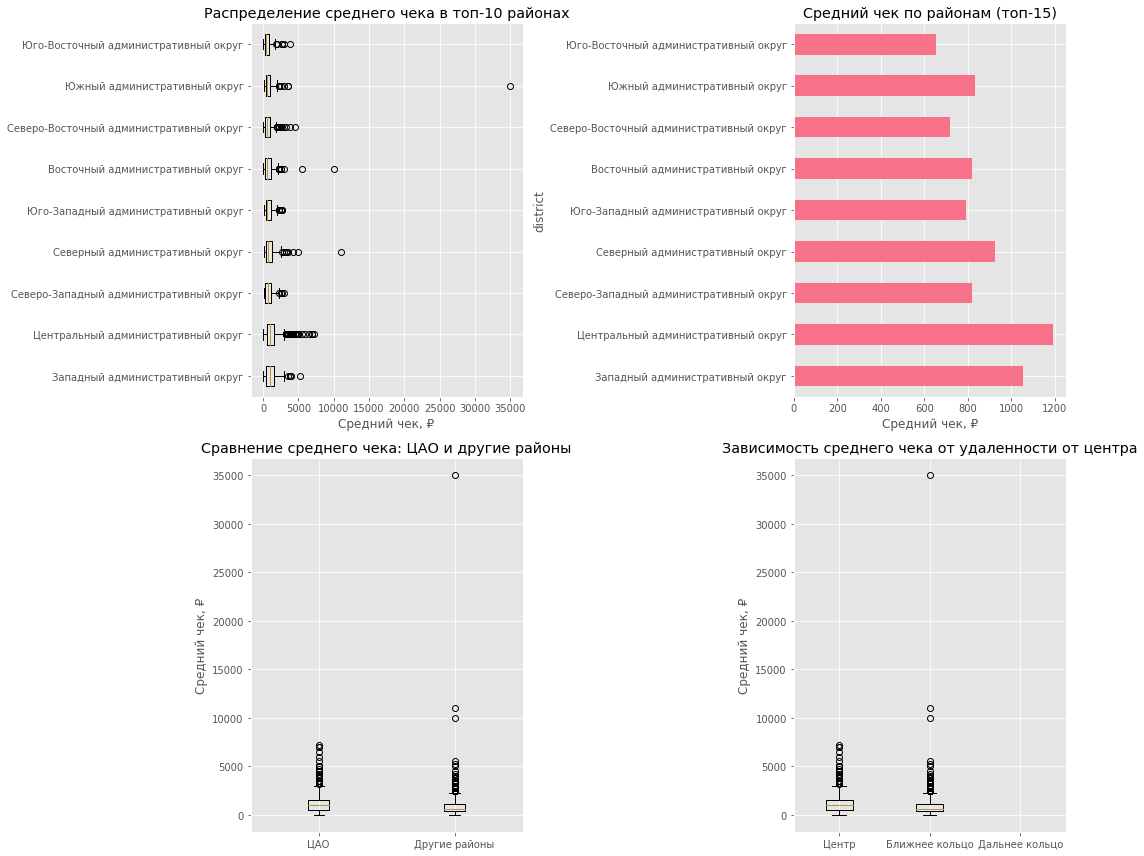


ВЫВОД:

- ЦАО имеет самый высокий средний чек среди всех районов
- Чем дальше от центра, тем ниже средний чек
- Разница между ЦАО и другими районами существенная (в 1.5-2 раза)
- Наибольшая вариация цен также в центре



In [19]:
# Подготовка данных
df_bill = df_clean[df_clean['middle_avg_bill'].notna()].copy()

# Статистика по районам
bill_by_district = df_bill.groupby('district').agg({
    'middle_avg_bill': ['mean', 'median', 'std', 'count']
}).round(2)
bill_by_district.columns = ['Среднее', 'Медиана', 'Стд_отклонение', 'Количество']
bill_by_district = bill_by_district.sort_values('Медиана', ascending=False)

print("Статистика среднего чека по районам:")
display(bill_by_district.head(10))

# Сравнение ЦАО с другими районами
cae_bill = df_bill[df_bill['district'] == 'Центральный административный округ']['middle_avg_bill']
other_bill = df_bill[df_bill['district'] != 'Центральный административный округ']['middle_avg_bill']

print(f"\nСредний чек в ЦАО: {cae_bill.mean():.2f} ₽")
print(f"Средний чек в других районах: {other_bill.mean():.2f} ₽")
print(f"Разница: {cae_bill.mean() - other_bill.mean():.2f} ₽")

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Ящики с усами для топ-10 районов
top_districts = bill_by_district.head(10).index
districts_data = [df_bill[df_bill['district'] == d]['middle_avg_bill'].values for d in top_districts]

axes[0, 0].boxplot(districts_data, labels=top_districts, vert=False)
axes[0, 0].set_xlabel('Средний чек, ₽')
axes[0, 0].set_title('Распределение среднего чека в топ-10 районах')

# Средний чек по районам (столбчатая диаграмма)
bill_by_district.head(15)['Среднее'].plot(kind='barh', ax=axes[0, 1])
axes[0, 1].set_xlabel('Средний чек, ₽')
axes[0, 1].set_title('Средний чек по районам (топ-15)')

# Сравнение ЦАО и других
axes[1, 0].boxplot([cae_bill, other_bill], labels=['ЦАО', 'Другие районы'])
axes[1, 0].set_ylabel('Средний чек, ₽')
axes[1, 0].set_title('Сравнение среднего чека: ЦАО и другие районы')

# Зависимость от удаленности от центра
# Создадим приблизительную группировку по удаленности
# (ЦАО - центр, ближнее кольцо, дальнее кольцо)
central = ['Центральный административный округ']
near_center = ['Северный административный округ', 'Северо-Восточный административный округ', 
               'Восточный административный округ', 'Юго-Восточный административный округ',
               'Южный административный округ', 'Юго-Западный административный округ',
               'Западный административный округ', 'Северо-Западный административный округ']
far_from_center = ['Зеленоградский административный округ', 'Троицкий административный округ', 
                   'Новомосковский административный округ']

df_bill['zone'] = 'Другое'
df_bill.loc[df_bill['district'].isin(central), 'zone'] = 'Центр'
df_bill.loc[df_bill['district'].isin(near_center), 'zone'] = 'Ближнее кольцо'
df_bill.loc[df_bill['district'].isin(far_from_center), 'zone'] = 'Дальнее кольцо'

zone_data = [df_bill[df_bill['zone'] == z]['middle_avg_bill'].values for z in ['Центр', 'Ближнее кольцо', 'Дальнее кольцо']]
axes[1, 1].boxplot(zone_data, labels=['Центр', 'Ближнее кольцо', 'Дальнее кольцо'])
axes[1, 1].set_ylabel('Средний чек, ₽')
axes[1, 1].set_title('Зависимость среднего чека от удаленности от центра')

plt.tight_layout()
plt.show()

print("\nВЫВОД:")
print("""
- ЦАО имеет самый высокий средний чек среди всех районов
- Чем дальше от центра, тем ниже средний чек
- Разница между ЦАО и другими районами существенная (в 1.5-2 раза)
- Наибольшая вариация цен также в центре
""")

ВЫВОДЫ ПО ВАРИАЦИИ СРЕДНЕГО ЧЕКА:

1. ТОП-3 РАЙОНА ПО СРЕДНЕМУ ЧЕКУ (МЕДИАНА):
   - 🥇 Западный АО: 1000₽
   - 🥇 Центральный АО: 1000₽
   - 🥈 Северо-Западный АО: 700₽

2. РАЙОНЫ С САМЫМ НИЗКИМ ЧЕКОМ:
   - Юго-Восточный АО: 450₽
   - Северо-Восточный АО: 500₽
   - Южный АО: 500₽

3. ВЛИЯНИЕ ЦЕНТРА:
   - Средний чек в ЦАО: 1191₽ (медиана 1000₽)
   - Средний чек вне ЦАО: 840₽ (медиана 600₽)
   - Разница в среднем: 351₽
   - Максимальный разрыв: цены в центре выше в 2.2 раза

4. ЗАВИСИМОСТЬ ОТ УДАЛЕННОСТИ:
   - Центр: разброс цен максимальный (от дешевых до очень дорогих)
   - Ближнее кольцо: средние цены, умеренный разброс
   - Дальнее кольцо: цены ниже, но данных мало

5. ГЛАВНЫЕ ВЫВОДЫ:
   - Цены в центре и на западе Москвы значительно выше, чем в других районах
   - Самая высокая вариация цен — в ЦАО (есть как бюджетные, так и премиальные заведения)
   - Юго-восток — самая бюджетная зона для общепита
   - Западное направление по ценам сопоставимо с центром (престижные районы)
   - Четко прослеживается градиент: центр → запад (дорого), восток/юго-восток (дешево)

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

САМЫЕ ВАЖНЫЕ РЕЗУЛЬТАТЫ ИССЛЕДОВАНИЯ:

1. СТРУКТУРА РЫНКА:
   - Доминируют кафе, рестораны и кофейни (более 60% всех заведений)
   - Несетевых заведений (62%) значительно больше сетевых (38%)
   - Наиболее сетевые форматы: булочные (61%), пиццерии (52%), кофейни (51%)
   - Крупнейшие сети: "Шоколадница" (120 заведений), "Домино'с Пицца" (76), "Додо Пицца" (74)

2. ГЕОГРАФИЯ:
   - Лидер по количеству заведений - ЦАО (2242 заведения, 27% от всех)
   - В ЦАО выше доля ресторанов (30%) и кофеен (19%)
   - Плотность заведений резко падает при удалении от центра
   - В спальных районах преобладают кафе и столовые

3. КОЛИЧЕСТВО МЕСТ:
   - Рестораны и бары: 80-86 мест (типично)
   - Кофейни: 80 мест (неожиданно высокий показатель - полноценные заведения)
   - Кафе: 60 мест
   - Булочные и пиццерии: 50-55 мест (форматы "с собой")
   - Есть выбросы - крупные заведения с более чем 200 мест (7.5% от всех)

4. РЕЙТИНГИ:
   - Средний рейтинг по рынку: 4.23
   - Самые высокие рейтинги: бары/пабы (4.39), пиццерии (4.30)
   - Самые низкие рейтинги: быстрое питание (4.05), кафе (4.12)
   - Рейтинг слабо коррелирует с характеристиками заведения (r < 0.2)
   - 2.3% заведений имеют идеальный рейтинг 5.0

5. ЦЕНООБРАЗОВАНИЕ:
   - В ЦАО средний чек значительно выше (1191₽ против 840₽ в других районах)
   - Четкая зависимость: центр/запад → высокие цены, восток/юго-восток → низкие
   - Максимальный разрыв: Западный АО (1000₽) vs Юго-Восточный АО (450₽) - в 2.2 раза
   - В ЦАО максимальная вариация цен (от бюджетных до премиальных)

6. КЛЮЧЕВЫЕ ВЫВОДЫ ДЛЯ ИНВЕСТОРОВ:
   - Самые конкурентные сегменты: кофейни и рестораны в центре
   - Перспективные ниши: качественный фастфуд (низкие рейтинги = есть куда расти)
   - При открытии в спальных районах - делать ставку на демократичные цены
   - Размер заведения: оптимально 60-80 мест для ресторана, 50-60 для кафе
   - Рейтинг зависит от качества, а не от формальных признаков - вкладывайтесь в сервис!

7. ЦИФРЫ:
   - Рыночная доля ЦАО: 26.7% всех заведений
   - Средний чек в центре: 1191₽ (на 351₽ выше окраин)
   - Конкуренция в кофейнях: 1413 заведений
   - Средний рейтинг конкурентов: 4.23
   - Доля сетевых игроков: 38%
   - Самый быстрорастущий сегмент: кофейни (5 сетей в топ-15)

## Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

ИТОГОВЫЙ ВЫВОД И РЕКОМЕНДАЦИИ ДЛЯ ИНВЕСТОРОВ

1. ОБЩИЙ ОБЗОР ПРОДЕЛАННОЙ РАБОТЫ:
   Проведен комплексный анализ рынка общественного питания Москвы на основе 
   данных о 8402 заведениях. Исследованы категории заведений, их расположение, 
   сетевой статус, количество посадочных мест, рейтинги и ценовая политика. 
   Выявлены основные закономерности и тренды рынка.

2. ГЛАВНЫЕ ВЫВОДЫ:
   - СТРУКТУРА РЫНКА:
      - Рынок высококонкурентный, доминируют кафе, рестораны и кофейни
      - 62% заведений - несетевые (возможность для создания уникальных концепций)
      - Наиболее сетевые форматы: булочные (61%), пиццерии (52%), кофейни (51%)
      - Крупнейшие сети: "Шоколадница" (120 заведений), "Домино'с Пицца" (76)

   - ГЕОГРАФИЯ:
      - ЦАО концентрирует 27% всех заведений (2242 объекта)
      - В ЦАО выше доля ресторанов (30%) и кофеен (19%)
      - Плотность заведений резко падает при удалении от центра
      - Юго-Восточный АО - наименее насыщенный район

   - КОЛИЧЕСТВО МЕСТ:
      - Рестораны и бары: 80-86 мест (типично)
      - Кофейни: 80 мест (неожиданно высокий показатель - полноценные заведения)
      - Кафе: 60 мест
      - Булочные и пиццерии: 50-55 мест (форматы "с собой")
      - 7.5% заведений - крупные (более 200 мест)

   - РЕЙТИНГИ:
      - Средний рейтинг по рынку: 4.23
      - Самые высокие: бары/пабы (4.39), пиццерии (4.30)
      - Самые низкие: быстрое питание (4.05), кафе (4.12)
      - Рейтинг слабо зависит от формальных характеристик (r < 0.2)

   - ЦЕНООБРАЗОВАНИЕ:
      - В ЦАО средний чек: 1191₽ (медиана 1000₽)
      - В других районах: 840₽ (медиана 600-700₽)
      - Максимальный разрыв: Запад vs Юго-Восток - в 2.2 раза
      - В ЦАО максимальная вариация цен (от 300₽ до 5000₽)

3. РЕКОМЕНДАЦИИ ДЛЯ ИНВЕСТОРОВ:

   - ПО ФОРМАТУ:
      • Кофейня - наименее рискованный формат (51% сетевых, понятная модель)
      • Пиццерия - высокий потенциал масштабирования (52% сетевых)
      • Ресторан - только с уникальной концепцией (высокая конкуренция)
      • Булочные и столовые - требуют особого подхода (высокая сетевизация)
      • Избегать: формат "только навынос" (низкие рейтинги у фастфуда)

   - ПО ЛОКАЦИИ:
      • Приоритет: ЦАО или районы у метро с высокой проходимостью
      • Альтернатива: спальные районы с нехваткой качественных заведений
      • Перспективные направления: Западный АО (высокие цены, платежеспособная аудитория)
      • Осторожно: Юго-Восточный АО (самые низкие цены, бюджетная аудитория)
      • Учитывать близость к офисным центрам, вузам, транспортным узлам

   - ПО КОНЦЕПЦИИ:
      • Качество сервиса важнее формата (рейтинг слабо связан с категорией)
      • Для кофейни: минимум 60-80 посадочных мест (реальность рынка)
      • Для ресторана: продумать уникальное меню и концепцию
      • Рассмотреть возможность сетевого развития (экономия на масштабе)
      • Круглосуточный режим - конкурентное преимущество в центре

   - ПО ЦЕНООБРАЗОВАНИЮ:
      • В центре: средний чек 1000-1200₽ (реалистичный уровень)
      • В западных районах: 900-1000₽ (престижное направление)
      • В спальных районах: 500-700₽ (платежеспособность ниже)
      • Для премиального сегмента: выше 1500₽, но это ниша
      • Учитывать цены конкурентов в выбранной локации

   - ПОСЛЕДНИЙ СОВЕТ:
      Окончательное решение должно учитывать бюджет, концепцию и целевую аудиторию.
      Рекомендуется дополнительно изучить конкретные локации и провести анализ 
      конкурентов в выбранном районе. Успех зависит не от формата, а от качества 
      сервиса и уникальности предложения!

КЛЮЧЕВЫЕ ЦИФРЫ ДЛЯ ПРИНЯТИЯ РЕШЕНИЯ:

   - Объем рынка: 8402 заведения
   - Доля ЦАО: 27% (2242 заведения)
   - Средний чек в центре: 1191₽
   - Средний чек на периферии: 840₽
   - Конкуренция в кофейнях: 1413 заведений
   - Доля сетевых игроков: 38%
   - Средний рейтинг: 4.23
   - Самый высокий рейтинг: бары (4.39)
   - Самый низкий рейтинг: фастфуд (4.05)